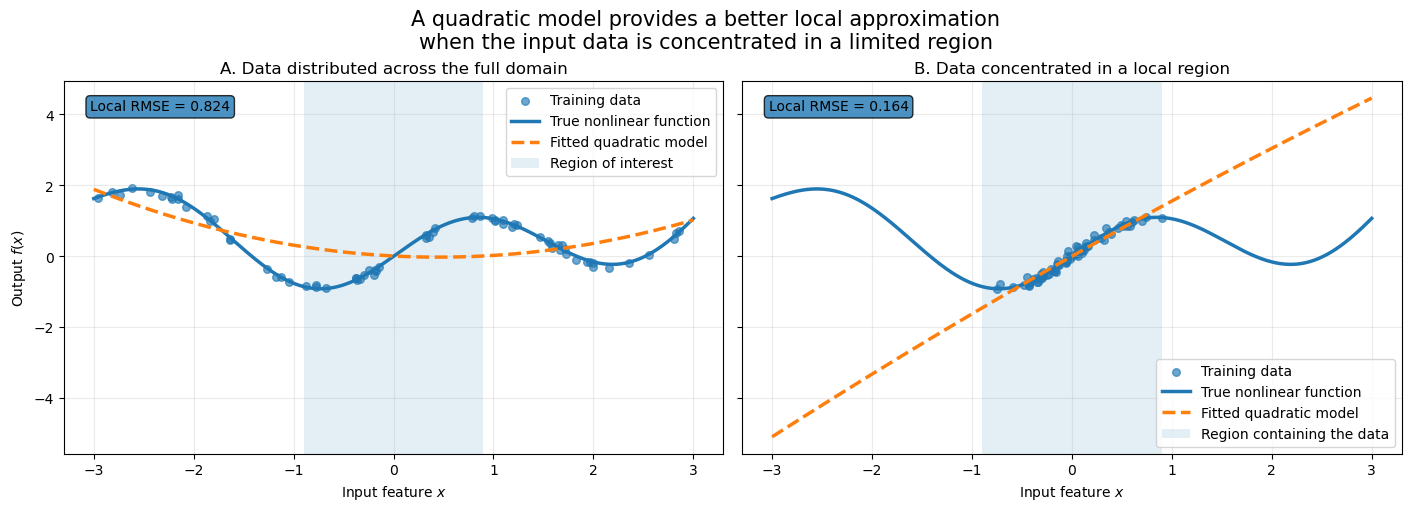

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define a nonlinear target function
# ------------------------------------------------------------
# This function is deliberately not quadratic.
def true_function(x):
    return np.sin(2 * x) + 0.15 * x**2


# ------------------------------------------------------------
# 2. Function for fitting a quadratic model
# ------------------------------------------------------------
def fit_quadratic(x, y):
    """
    Fits the model

        y_hat = a*x^2 + b*x + c

    using least squares.
    """
    coefficients = np.polyfit(x, y, deg=2)
    return coefficients


def predict_quadratic(x, coefficients):
    return np.polyval(coefficients, x)


# ------------------------------------------------------------
# 3. Generate two different training datasets
# ------------------------------------------------------------
rng = np.random.default_rng(seed=42)

n_samples = 70
noise_std = 0.08

# Case 1: Data distributed across the entire domain
x_distributed = rng.uniform(-3, 3, n_samples)
y_distributed = (
    true_function(x_distributed)
    + rng.normal(0, noise_std, n_samples)
)

# Case 2: Data concentrated around x = 0
x_focused = rng.normal(
    loc=0.0,
    scale=0.35,
    size=n_samples
)

# Keep all focused observations inside the local region
x_focused = np.clip(x_focused, -0.9, 0.9)

y_focused = (
    true_function(x_focused)
    + rng.normal(0, noise_std, n_samples)
)


# ------------------------------------------------------------
# 4. Fit one quadratic model to each dataset
# ------------------------------------------------------------
coef_distributed = fit_quadratic(
    x_distributed,
    y_distributed
)

coef_focused = fit_quadratic(
    x_focused,
    y_focused
)


# ------------------------------------------------------------
# 5. Evaluate the fitted models
# ------------------------------------------------------------
x_plot = np.linspace(-3, 3, 1000)

y_true = true_function(x_plot)

y_fit_distributed = predict_quadratic(
    x_plot,
    coef_distributed
)

y_fit_focused = predict_quadratic(
    x_plot,
    coef_focused
)


# Define the region in which the data is concentrated
focus_lower = -0.9
focus_upper = 0.9

focus_mask = (
    (x_plot >= focus_lower)
    & (x_plot <= focus_upper)
)


# Calculate the local errors inside the focused region
local_rmse_distributed = np.sqrt(
    np.mean(
        (
            y_true[focus_mask]
            - y_fit_distributed[focus_mask]
        )**2
    )
)

local_rmse_focused = np.sqrt(
    np.mean(
        (
            y_true[focus_mask]
            - y_fit_focused[focus_mask]
        )**2
    )
)


# ------------------------------------------------------------
# 6. Plot the comparison
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)


# ------------------------------------------------------------
# Left plot: Distributed data
# ------------------------------------------------------------
axes[0].scatter(
    x_distributed,
    y_distributed,
    alpha=0.65,
    s=30,
    label="Training data"
)

axes[0].plot(
    x_plot,
    y_true,
    linewidth=2.5,
    label="True nonlinear function"
)

axes[0].plot(
    x_plot,
    y_fit_distributed,
    linestyle="--",
    linewidth=2.5,
    label="Fitted quadratic model"
)

axes[0].axvspan(
    focus_lower,
    focus_upper,
    alpha=0.12,
    label="Region of interest"
)

axes[0].set_title(
    "A. Data distributed across the full domain"
)

axes[0].set_xlabel("Input feature $x$")
axes[0].set_ylabel("Output $f(x)$")

axes[0].text(
    0.04,
    0.95,
    f"Local RMSE = {local_rmse_distributed:.3f}",
    transform=axes[0].transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "alpha": 0.8
    }
)

axes[0].grid(alpha=0.25)
axes[0].legend()


# ------------------------------------------------------------
# Right plot: Focused data
# ------------------------------------------------------------
axes[1].scatter(
    x_focused,
    y_focused,
    alpha=0.65,
    s=30,
    label="Training data"
)

axes[1].plot(
    x_plot,
    y_true,
    linewidth=2.5,
    label="True nonlinear function"
)

axes[1].plot(
    x_plot,
    y_fit_focused,
    linestyle="--",
    linewidth=2.5,
    label="Fitted quadratic model"
)

axes[1].axvspan(
    focus_lower,
    focus_upper,
    alpha=0.12,
    label="Region containing the data"
)

axes[1].set_title(
    "B. Data concentrated in a local region"
)

axes[1].set_xlabel("Input feature $x$")

axes[1].text(
    0.04,
    0.95,
    f"Local RMSE = {local_rmse_focused:.3f}",
    transform=axes[1].transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "alpha": 0.8
    }
)

axes[1].grid(alpha=0.25)
axes[1].legend()


fig.suptitle(
    "A quadratic model provides a better local approximation\n"
    "when the input data is concentrated in a limited region",
    fontsize=15
)

plt.savefig(
    "quadratic_local_approximation.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "quadratic_local_approximation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()